# Climate-Health Early Warning System

## Phase 1: Exploratory Data Analysis (EDA)


### 1. Environment Setup & Dependency Loading


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Notebook configuration
pd.set_option('display.max_columns', None)
load_dotenv()

print("Initialization complete. All dependencies successfully loaded.")

Initialization complete. All dependencies successfully loaded.


### 2. Data Ingestion


In [7]:
DATA_PATH = "../data/raw/global_climate_health_impact_tracker_2015_2025.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataset Shape: 14100 rows, 30 columns.


### 3. Data Profiling & Structural Inspection


In [10]:
df.head()

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,longitude,population_millions,temperature_celsius,temp_anomaly_celsius,precipitation_mm,heat_wave_days,drought_indicator,flood_indicator,extreme_weather_events,pm25_ugm3,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
0,1,USA,United States,North America,High,2015-01-04,2015,1,1,37.09,-95.71,331,4.59,0.76,75.7,0,0,0,0,39.0,82.0,69.4,31.5,6.6,16.2,1.4,77.3,63627.0,71.2,90.2
1,2,USA,United States,North America,High,2015-01-11,2015,1,2,37.09,-95.71,331,3.13,-0.50,97.0,0,0,0,0,17.9,6.0,70.0,26.3,5.2,11.4,0.0,83.6,63627.0,70.6,94.0
2,3,USA,United States,North America,High,2015-01-18,2015,1,3,37.09,-95.71,331,3.99,-0.14,74.1,0,0,0,0,91.5,137.0,66.9,33.4,1.3,19.5,0.0,84.7,63627.0,63.4,100.0
3,4,USA,United States,North America,High,2015-01-25,2015,1,4,37.09,-95.71,331,6.43,-0.06,87.7,0,0,0,0,5.5,-3.0,47.0,35.0,6.0,9.7,9.0,84.3,63627.0,68.1,96.4
4,5,USA,United States,North America,High,2015-02-01,2015,2,5,37.09,-95.71,331,9.00,0.47,75.8,1,0,0,1,37.1,48.0,61.3,28.3,1.4,22.6,27.3,83.6,63733.0,69.1,100.0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14100 entries, 0 to 14099
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     14100 non-null  int64  
 1   country_code                  14100 non-null  str    
 2   country_name                  14100 non-null  str    
 3   region                        14100 non-null  str    
 4   income_level                  14100 non-null  str    
 5   date                          14100 non-null  str    
 6   year                          14100 non-null  int64  
 7   month                         14100 non-null  int64  
 8   week                          14100 non-null  int64  
 9   latitude                      14100 non-null  float64
 10  longitude                     14100 non-null  float64
 11  population_millions           14100 non-null  int64  
 12  temperature_celsius           14100 non-null  float64
 13  temp_anomaly

In [32]:
df.describe()

,record_id,date,year,month,week,latitude,longitude,population_millions,temperature_celsius,temp_anomaly_celsius,precipitation_mm,heat_wave_days,drought_indicator,flood_indicator,extreme_weather_events,pm25_ugm3,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
count,14100.000000,14100,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000
mean,7050.500000,2020-05-27 12:00:00,2019.911348,6.437943,26.221631,18.905200,27.349600,217.440000,8.607113,0.120879,81.149440,0.148085,0.011560,0.005887,0.165532,65.773752,98.750071,70.016872,30.758596,12.096277,22.172965,6.880794,64.875674,26331.105887,69.874638,93.295780
min,1.000000,2015-01-04 00:00:00,2015.000000,1.000000,1.000000,-38.410000,-106.340000,26.000000,-20.740000,-1.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-52.000000,21.200000,8.000000,0.000000,0.000000,0.000000,27.900000,1565.000000,47.700000,62.200000
25%,3525.750000,2017-09-15 06:00:00,2017.000000,3.000000,13.000000,4.570000,-3.740000,60.000000,0.257500,-0.220000,51.500000,0.000000,0.000000,0.000000,0.000000,36.600000,54.000000,59.200000,27.000000,3.500000,17.800000,0.000000,47.100000,3548.000000,66.500000,88.800000
50%,7050.500000,2020-05-27 12:00:00,2020.000000,6.000000,26.000000,23.630000,22.930000,98.000000,8.630000,0.120000,80.900000,0.000000,0.000000,0.000000,0.000000,61.200000,93.000000,69.600000,30.800000,5.800000,22.100000,0.600000,66.600000,13941.000000,70.000000,94.400000
75%,10575.250000,2023-02-06 18:00:00,2023.000000,9.000000,39.000000,37.090000,100.990000,206.000000,16.850000,0.460000,110.600000,0.000000,0.000000,0.000000,0.000000,94.300000,142.000000,80.500000,34.500000,8.900000,26.400000,12.300000,81.500000,50206.500000,73.300000,99.700000
max,14100.000000,2025-10-19 00:00:00,2025.000000,12.000000,53.000000,56.130000,138.250000,1411.000000,38.330000,2.120000,222.900000,5.000000,1.000000,1.000000,5.000000,189.500000,302.000000,131.800000,51.100000,100.000000,63.000000,59.600000,102.000000,78630.000000,88.700000,100.000000
std,4070.463733,NaN,3.118225,3.421173,14.930110,25.730498,76.062029,355.979373,11.289938,0.506365,40.821462,0.455931,0.106899,0.076500,0.475788,38.102525,59.143284,15.223261,5.605436,17.146545,6.609017,9.498276,18.230095,26329.114275,5.025983,6.295667


### 4. Data Quality & Integrity Assessment

In this section, we perform a comprehensive evaluation of data quality, including missing value profiling and logical integrity verification based on domain knowledge.


#### 4.1. Missing Value Profiling

Check for any null or missing values across all features in the dataset.


In [12]:
# Compute and filter columns with missing values
missing_counts = df.isnull().sum()
missing_summary = missing_counts[missing_counts > 0]

print("Columns containing missing values:")
if not missing_summary.empty:
    print(missing_summary)
else:
    print("Excellent! No missing values detected in the raw dataset.")

Columns containing missing values:
Excellent! No missing values detected in the raw dataset.


#### 4.2. Logical Integrity & Domain-Specific Validation

Validate that the data adheres to logical constraints (e.g., geographic coordinate ranges, AQI bounds, and binary indicator consistency).


In [22]:
# 1. Duplicate Check
duplicate_count = df.duplicated(subset=['record_id']).sum()
print(f"Number of duplicate records (based on record_id): {duplicate_count}")

# 2. Range Validation
# Based on column_descriptions_climate_health.md
validation_rules = {
    'latitude': (-90, 90),
    'longitude': (-180, 180),
    'heat_wave_days': (0, 7),
    'air_quality_index': (0, 500)
}

print("\nData Range Verification:")
for col, (min_val, max_val) in validation_rules.items():
    out_of_range = df[(df[col] < min_val) | (df[col] > max_val)]
    print(f"- {col}: {len(out_of_range)} out-of-range values detected ({min_val} to {max_val}).")

# 3. Binary Consistency Check (0 or 1)
binary_cols = ['drought_indicator', 'flood_indicator']
print("\nBinary Column Consistency Check:")
for col in binary_cols:
    invalid_binary = df[~df[col].isin([0, 1])]
    print(f"- {col}: {len(invalid_binary)} invalid values (not 0 or 1).")

# 4. Categorical Consistency
categorical_features = ['region', 'income_level', 'country_name']
print("\nCategorical Feature Statistics:")
for col in categorical_features:
    unique_vals = df[col].nunique()
    print(f"- {col}: {unique_vals} unique values.")

print("\n--- Data Verification Complete ---")

Number of duplicate records (based on record_id): 0

Data Range Verification:
- latitude: 0 out-of-range values detected (-90 to 90).
- longitude: 0 out-of-range values detected (-180 to 180).
- heat_wave_days: 0 out-of-range values detected (0 to 7).
- air_quality_index: 374 out-of-range values detected (0 to 500).

Binary Column Consistency Check:
- drought_indicator: 0 invalid values (not 0 or 1).
- flood_indicator: 0 invalid values (not 0 or 1).

Categorical Feature Statistics:
- region: 8 unique values.
- income_level: 3 unique values.
- country_name: 25 unique values.

--- Data Verification Complete ---


In [39]:
# Deep Dive: Investigating Air Quality Index (AQI) values outside [0, 500] range
aqi_invalid = df[(df['air_quality_index'] < 0) | (df['air_quality_index'] > 500)]
print(f"Number of invalid AQI records: {len(aqi_invalid)}")

if len(aqi_invalid) > 0:
    country_counts = aqi_invalid['country_name'].value_counts().reset_index()
    
    country_counts.columns = ['country_name', 'invalid_records_count']
    
    print("\nInvalid AQI Statistics:")
    print(aqi_invalid['air_quality_index'].describe())
    
    print("\nSample of Invalid Records:")
    display(aqi_invalid[['country_name', 'date', 'air_quality_index']])
else:
    print("\nNo AQI values found outside [0, 500] range.")

Number of invalid AQI records: 374

Invalid AQI Statistics:
count    374.000000
mean     -10.834225
std        8.752437
min      -52.000000
25%      -15.000000
50%       -9.000000
75%       -4.000000
max       -1.000000
Name: air_quality_index, dtype: float64

Sample of Invalid Records:


,country_name,date,air_quality_index
3,United States,2015-01-25,-3.0
10,United States,2015-03-15,-23.0
36,United States,2015-09-13,-13.0
47,United States,2015-11-29,-1.0
60,United States,2016-02-28,-25.0
...,...,...,...
14020,Colombia,2024-04-14,-11.0
14021,Colombia,2024-04-21,-4.0
14032,Colombia,2024-07-07,-7.0
14036,Colombia,2024-08-04,-11.0


In [40]:
display(country_counts)

,country_name,invalid_records_count
0,Colombia,32
1,United States,31
2,Canada,27
3,United Kingdom,26
4,Argentina,26
5,China,25
6,South Africa,24
7,Brazil,23
8,Australia,22
9,Spain,22


#### 4.3. Temporal & Spatial Continuity

Verifying if the time series is continuous for all countries and if geographic coordinates are consistent per country.


In [30]:
# 1. Temporal Continuity Check (Weekly frequency)
df['date'] = pd.to_datetime(df['date'])
expected_weeks = df.groupby('country_name')['date'].nunique()
print("Observations per country (Expected to be consistent):")
print(expected_weeks.value_counts())

# check for any gaps in date sequence for one sample country
sample_country = df['country_name'].iloc[0]
country_dates = sorted(df[df['country_name'] == sample_country]['date'].unique())
date_diffs = pd.Series(country_dates).diff().dt.days.dropna().unique()
print(f"\nUnique day differences between consecutive records for {sample_country}: {date_diffs}")

# 2. Spatial Consistency (Lat/Long per Country)
geo_consistency = df.groupby('country_name')[['latitude', 'longitude']].nunique()
inconsistent_geo = geo_consistency[(geo_consistency['latitude'] > 1) | (geo_consistency['longitude'] > 1)]

if inconsistent_geo.empty:
    print("\nGeographic coordinates are consistent for all countries.")
else:
    print("\nWarning: Some countries have multiple coordinates detected:")
    print(inconsistent_geo)

Observations per country (Expected to be consistent):
date
564    25
Name: count, dtype: int64

Unique day differences between consecutive records for United States: [7.]

Geographic coordinates are consistent for all countries.


### 5. Temporal Trend & Seasonality Analysis


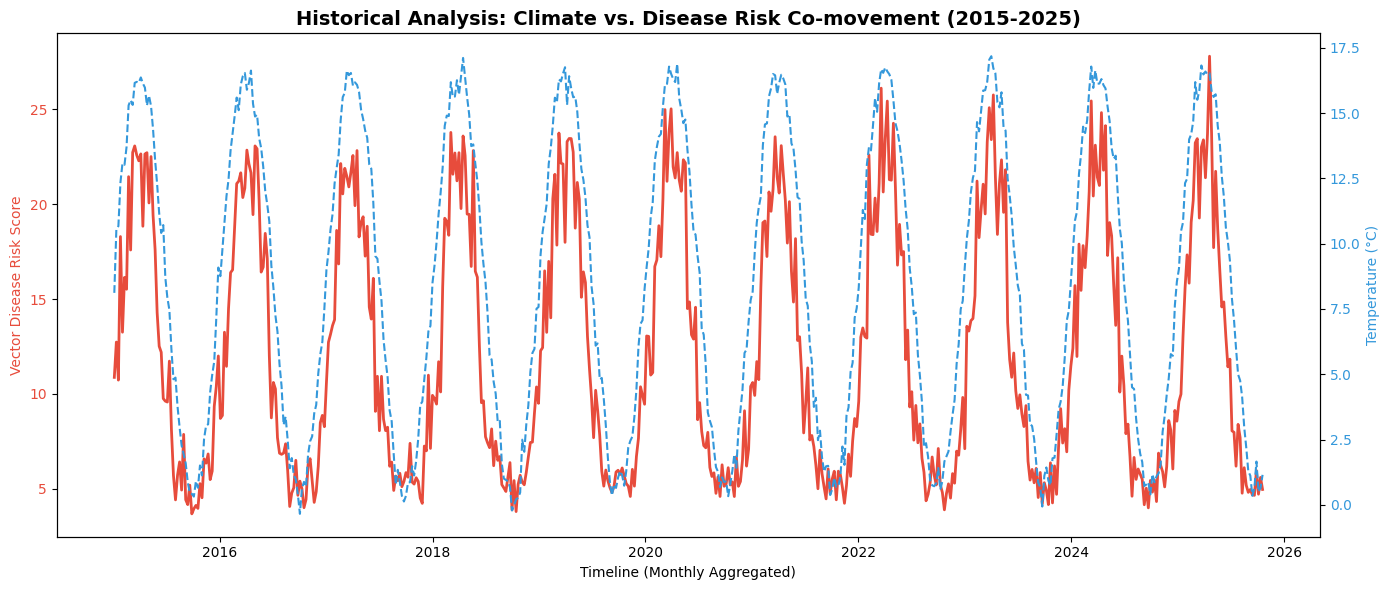

In [45]:
# Note: Date conversion already handled in Section 4.3

# Set date as index for advanced time-series resampling
df_time = df.set_index('date')

# Aggregate data by month globally to observe macro seasonality patterns
monthly_trends = df_time.resample('W')[['temperature_celsius', 'vector_disease_risk_score']].mean()

# Plotting the historical trend
fig, ax1 = plt.subplots(figsize=(14, 6))

color = '#e74c3c'
ax1.set_xlabel('Timeline (Monthly Aggregated)')
ax1.set_ylabel('Vector Disease Risk Score', color=color)
ax1.plot(monthly_trends.index, monthly_trends['vector_disease_risk_score'], color=color, linewidth=2, label='Disease Risk')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = '#3498db'
ax2.set_ylabel('Temperature (°C)', color=color)
ax2.plot(monthly_trends.index, monthly_trends['temperature_celsius'], color=color, linestyle='--', linewidth=1.5, label='Temperature')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Historical Analysis: Climate vs. Disease Risk Co-movement (2015-2025)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 6. Feature Distribution & Outlier Identification


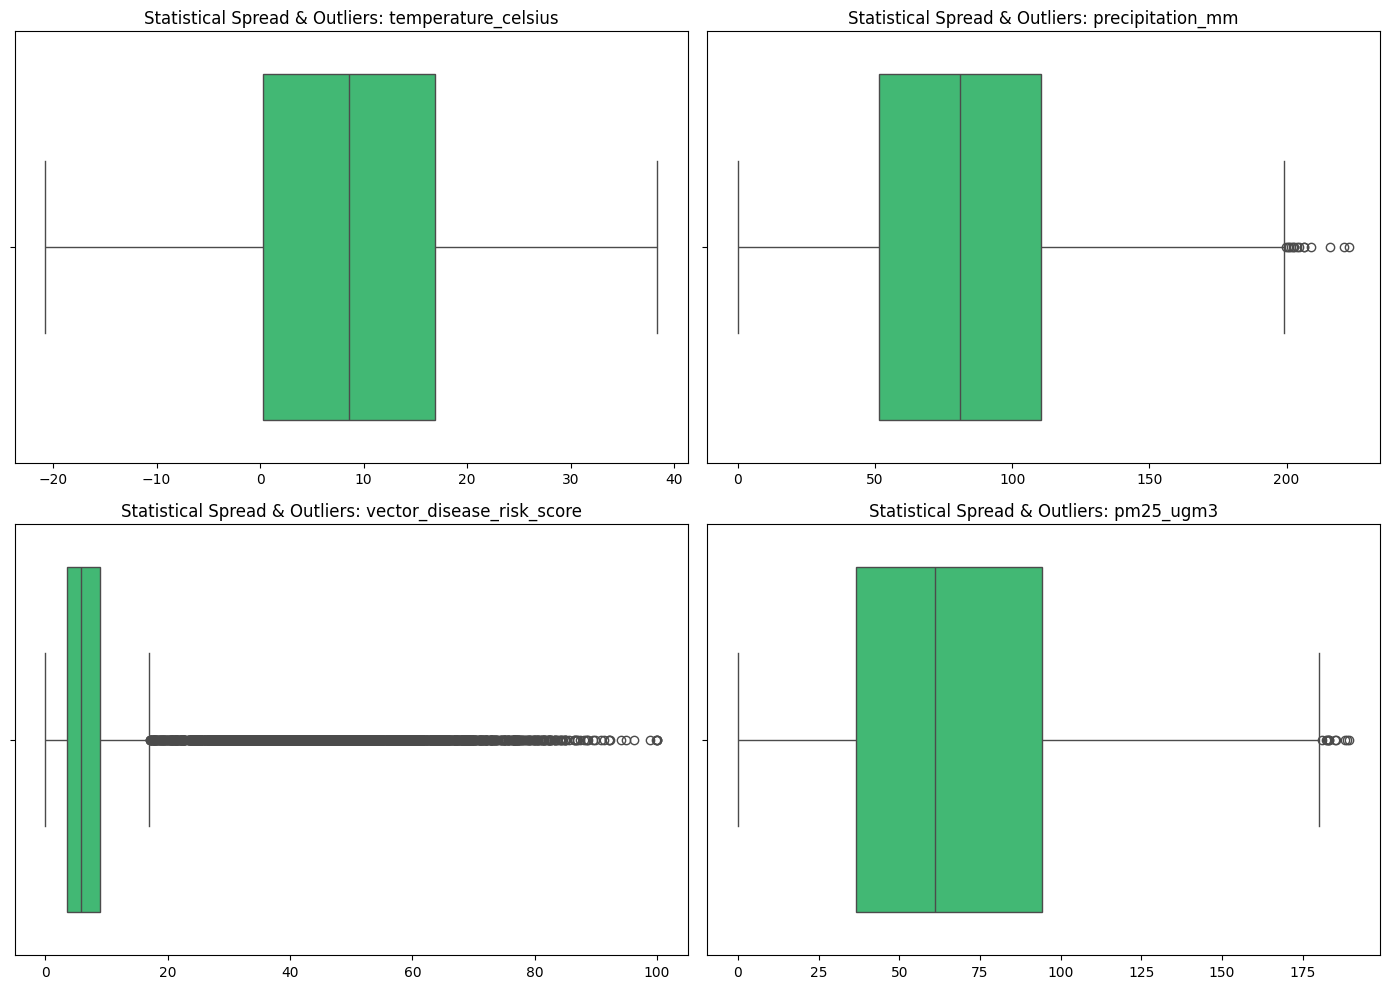

In [27]:
# Setup a subplots grid for distribution checks
features_to_check = ['temperature_celsius', 'precipitation_mm', 'vector_disease_risk_score', 'pm25_ugm3']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_check):
    sns.boxplot(data=df, x=col, ax=axes[i], color='#2ecc71')
    axes[i].set_title(f'Statistical Spread & Outliers: {col}', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 7. Correlation Analysis & Feature Interactions


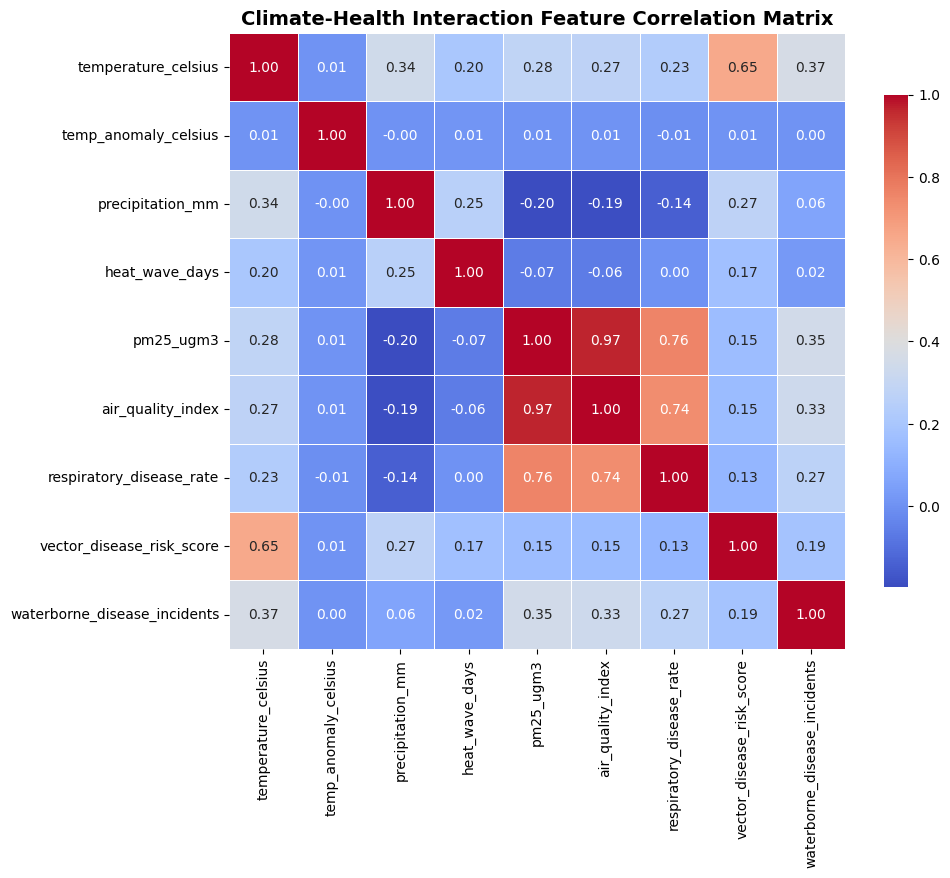

In [46]:
# Select numeric columns relevant to our predictive modeling target
numeric_cols = [
    'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm', 
    'heat_wave_days', 'pm25_ugm3', 'air_quality_index',
    'respiratory_disease_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents'
]

corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, linewidths=0.5)
plt.title('Climate-Health Interaction Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

### 8. Socioeconomic & Health System Context

Analyzing how climate-health outcomes vary across different socioeconomic levels (income, healthcare access).


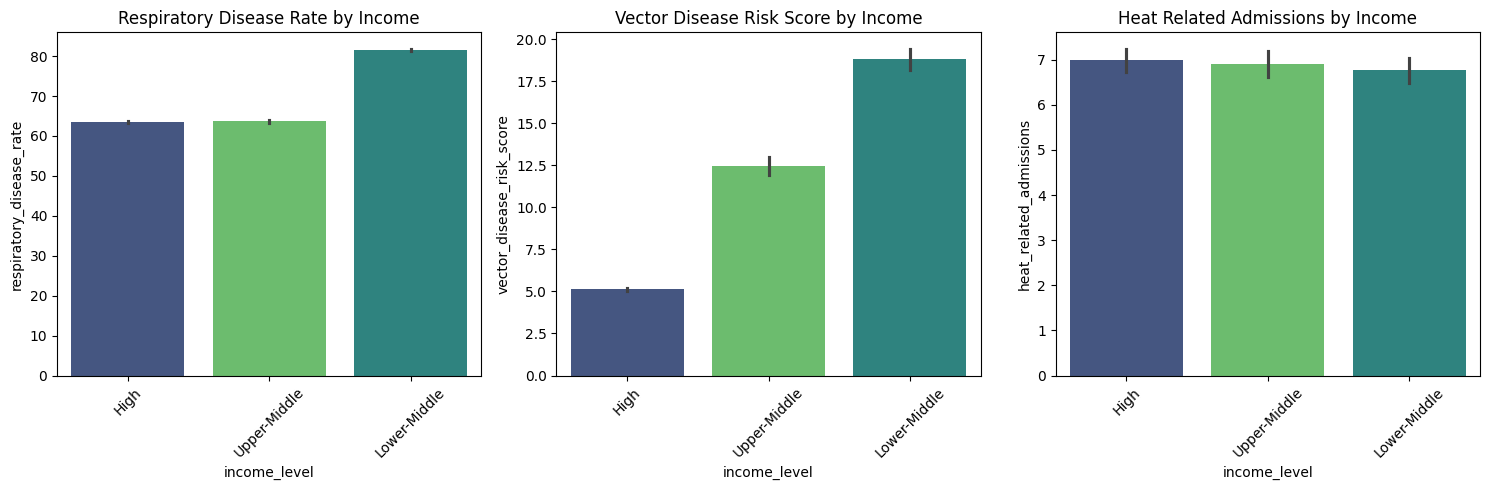

Correlation between Healthcare Access Index and Health Outcomes:
respiratory_disease_rate    -0.496938
vector_disease_risk_score   -0.324048
heat_related_admissions      0.010171
Name: healthcare_access_index, dtype: float64


In [48]:
# Compare health risks across income levels
health_metrics = ['respiratory_disease_rate', 'vector_disease_risk_score', 'heat_related_admissions']

plt.figure(figsize=(15, 5))
for i, metric in enumerate(health_metrics):
    plt.subplot(1, 3, i+1)
    
    # FIX Ở ĐÂY: Thêm hue='income_level' và legend=False
    sns.barplot(
        data=df, 
        x='income_level', 
        y=metric, 
        palette='viridis', 
        hue='income_level',  # Ép gán màu theo biến trục X
        legend=False,        # Tắt bảng chú thích (vì trục X đã ghi rõ tên nhóm rồi)
        order=['High', 'Upper-Middle', 'Lower-Middle']
    )
    
    plt.title(f'{metric.replace("_", " ").title()} by Income')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation between Healthcare Access and Disease Outcomes
print("Correlation between Healthcare Access Index and Health Outcomes:")
print(df[['healthcare_access_index'] + health_metrics].corr()['healthcare_access_index'].iloc[1:])